2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


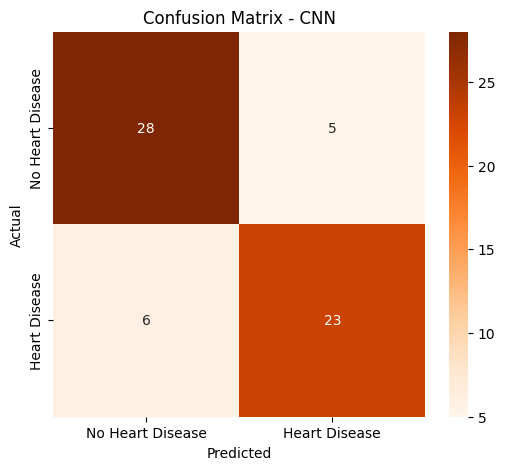

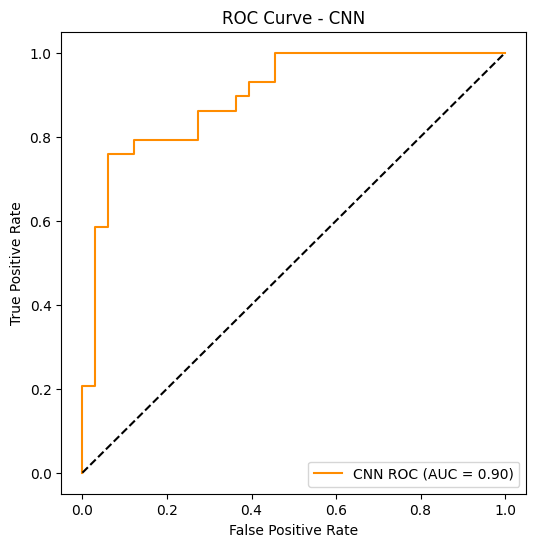

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Model Performance:

                    Model Accuracy Precision Recall F1 Score
                      CNN   82.26%    82.14% 79.31%   80.70%
                CNN + SVM   83.87%    88.00% 75.86%   81.48%
      CNN + Random Forest   82.26%    84.62% 75.86%   80.00%
            CNN + XGBoost   82.26%    82.14% 79.31%   80.70%
  CNN + Gradient Boosting   83.87%    80.65% 86.21%   83.33%
CNN + Logistic Regression   87.10%    88.89% 82.76%   85.71%

Best model based on accuracy: CNN + Logistic Regression


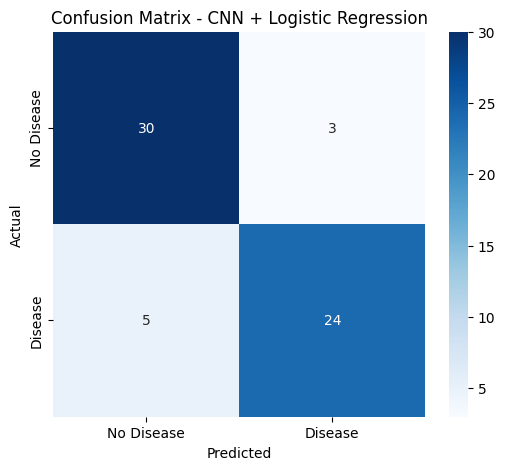

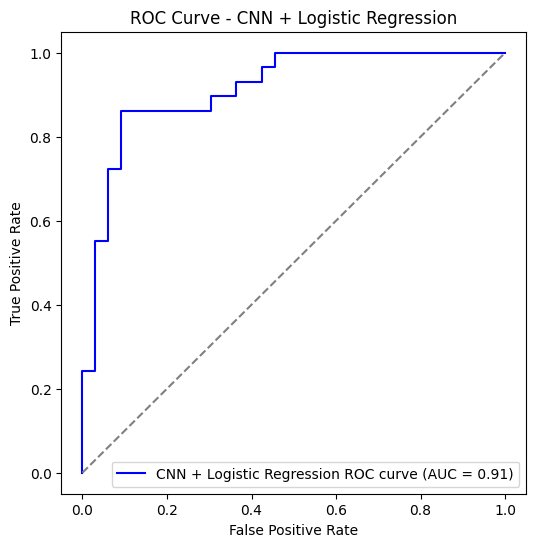

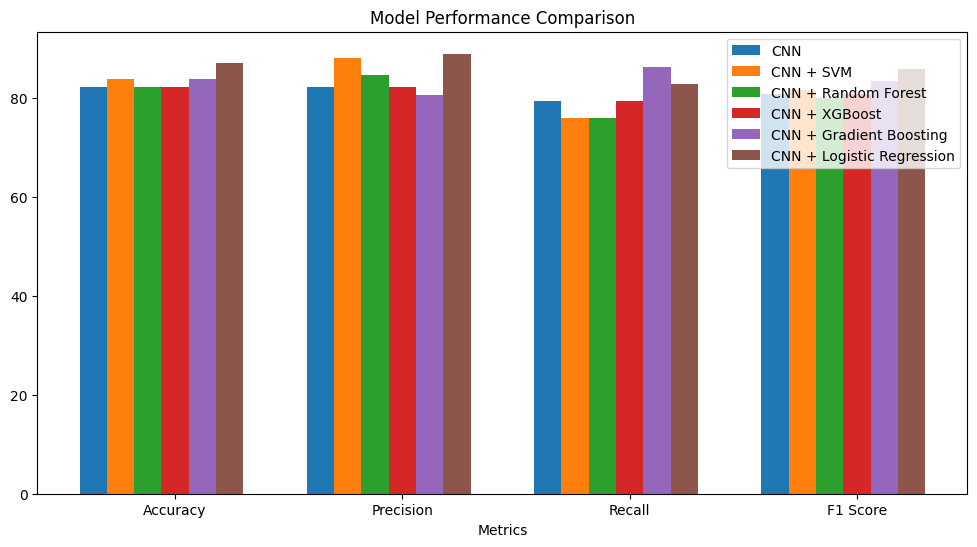

In [ ]:
import pandas as pd
import numpy as np
import random
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

!pip install tensorflow imbalanced-learn xgboost

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

# 1. Reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# 2. Load Dataset
df = pd.read_csv("heart_disease_uci.csv")

# 3. Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# 4. Clean and drop nulls
df.dropna(inplace=True)

# 5. Feature selection
paper_features = ['age', 'sex', 'cp', 'trestbps', 'chol',
                  'fbs', 'restecg', 'thalach', 'exang', 'oldpeak',
                  'slope', 'ca', 'thal']
paper_features = [col for col in paper_features if col in df.columns]
target_col = 'num'
df = df[paper_features + [target_col]]

# 6. Split features and binary target
X = df.drop(target_col, axis=1)
y = (df[target_col] > 0).astype(int)

# 7. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y)

# 8. Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 9. Build Enhanced CNN model
input_layer = Input(shape=(X_train.shape[1],))
x = Dense(512, activation='elu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(256, activation='elu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(128, activation='elu')(x)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)
x = Dense(64, activation='elu')(x)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)
x = Dense(32, activation='elu')(x)
features_out = Dense(24, activation='elu')(x)
output_layer = Dense(1, activation='sigmoid')(features_out)

cnn = Model(inputs=input_layer, outputs=output_layer)
cnn.compile(loss='binary_crossentropy', optimizer=Nadam(learning_rate=0.0005), metrics=['accuracy'])

# 10. Train with enhanced callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=7, min_lr=1e-6)
cnn.fit(X_train, y_train, epochs=200, batch_size=32,
        validation_data=(X_test, y_test), callbacks=[early_stop, reduce_lr], verbose=0)
# CNN Predictions for Evaluation
y_pred_cnn = (cnn.predict(X_test) > 0.5).astype(int).flatten()
y_prob_cnn = cnn.predict(X_test).flatten()

# Confusion Matrix for CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix - CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve for CNN
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_prob_cnn)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure(figsize=(6, 6))
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN ROC (AUC = {roc_auc_cnn:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - CNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


# 11. Extract Features from 24-unit Layer
feature_extractor = Model(inputs=cnn.input, outputs=features_out)
X_train_cnn = feature_extractor.predict(X_train)
X_test_cnn = feature_extractor.predict(X_test)

# 12. Scale Extracted Features for ML Models
scaler_ml = StandardScaler()
X_train_cnn = scaler_ml.fit_transform(X_train_cnn)
X_test_cnn = scaler_ml.transform(X_test_cnn)

# 13. Train Enhanced ML Models on CNN Features
models = {
    "SVM": SVC(kernel='linear', C=0.1, probability=True, random_state=seed),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_split=10, min_samples_leaf=3, random_state=seed),
    "XGBoost": XGBClassifier(n_estimators=90, max_depth=3, learning_rate=0.08, subsample=0.9, colsample_bytree=0.7, use_label_encoder=False, eval_metric='logloss', random_state=seed),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=80, learning_rate=0.04, max_depth=3, min_samples_split=10, min_samples_leaf=4, random_state=seed),
    "Logistic Regression": LogisticRegression(penalty='l1', solver='liblinear', C=0.4, max_iter=500, random_state=seed)
}

results = []
for name, clf in models.items():
    model_label = f"CNN + {name}"
    clf.fit(X_train_cnn, y_train)
    y_pred = clf.predict(X_test_cnn)

    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, zero_division=0) * 100
    rec = recall_score(y_test, y_pred, zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, zero_division=0) * 100

    results.append({
        "Model": model_label,
        "Accuracy": f"{acc:.2f}%",
        "Precision": f"{prec:.2f}%",
        "Recall": f"{rec:.2f}%",
        "F1 Score": f"{f1:.2f}%"
    })

# CNN standalone performance
y_pred_cnn = (cnn.predict(X_test) > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred_cnn) * 100
prec = precision_score(y_test, y_pred_cnn) * 100
rec = recall_score(y_test, y_pred_cnn) * 100
f1 = f1_score(y_test, y_pred_cnn) * 100
results.insert(0, {
    "Model": "CNN",
    "Accuracy": f"{acc:.2f}%",
    "Precision": f"{prec:.2f}%",
    "Recall": f"{rec:.2f}%",
    "F1 Score": f"{f1:.2f}%"
})

results_df = pd.DataFrame(results)
print("\nModel Performance:\n")
print(results_df.to_string(index=False))

# Confusion Matrix & ROC for Best Model
best_model_row = results_df.loc[results_df['Accuracy'].str.rstrip('%').astype(float).idxmax()]
best_model_name = best_model_row['Model']
print(f"\nBest model based on accuracy: {best_model_name}")

if best_model_name == "CNN":
    y_pred = y_pred_cnn
    y_prob = cnn.predict(X_test)
else:
    best_clf = models[best_model_name.replace("CNN + ", "")]
    y_pred = best_clf.predict(X_test_cnn)
    y_prob = best_clf.predict_proba(X_test_cnn)[:, 1]

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='b', label=f'{best_model_name} ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title(f'ROC Curve - {best_model_name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Bar Chart Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = results_df['Model'].tolist()
metrics_values = np.array([[float(val.replace('%', '')) for val in results_df.loc[results_df['Model'] == model, metrics].values[0]] for model in model_names])

x = np.arange(len(metrics))
width = 0.12

fig, ax = plt.subplots(figsize=(12, 6))
for i, model in enumerate(model_names):
    ax.bar(x + i * width, metrics_values[i], width, label=model)

ax.set_xlabel('Metrics')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * len(model_names) / 2)
ax.set_xticklabels(metrics)
ax.legend()
plt.show()
